## **Exercise 1**

In simple linear regression, we use the equation y = mx + b to represent the relationship between two variables. 

- a) What does each component of this equation represent?
- b) Given a line with a slope (m) of 2 and a y-intercept (b) of 3, write a Python function that calculates y for any given x.
- c) Use your function to calculate y when x is 0, 1, and 5.

Here's a template to get you started:

```python
def linear_function(x):
    # Your code here
    pass

# Test your function
print(linear_function(0))
print(linear_function(1))
print(linear_function(5))
```

In [1]:
# Answer here
def linear_function(x):
    return 2 * x + 3

print(linear_function(0))
print(linear_function(1))
print(linear_function(5))

3
5
13


## **Exercise 2**

In this exercise, you'll implement a simple linear regression model using the least squares method. You'll be given a set of data points, and your task is to find the best-fitting line.  Note that the least squares method is the method you learn in grade school math (not like gradient descent).

- a) Implement functions to calculate the mean of x and y values.
- b) Implement a function to calculate the slope (m) of the best-fitting line.
- c) Use the calculated slope to find the y-intercept (b).
- d) Create a function that predicts y values given x values using your calculated m and b.

Here's a template to get you started:

```python
import numpy as np
import matplotlib.pyplot as plt

# Sample data
x = np.array([1, 2, 3, 4, 5])
y = np.array([2, 4, 5, 4, 5])

def mean(values):
    # Calculate the mean of the given values
    pass

def calculate_slope(x, y):
    # Calculate the slope using the least squares method
    # Hint: Use the formula m = Σ((x - x_mean) * (y - y_mean)) / Σ((x - x_mean)^2)
    pass

def calculate_intercept(x, y, m):
    # Calculate the y-intercept using the formula b = y_mean - m * x_mean
    pass

def predict(x, m, b):
    # Predict y values using y = mx + b
    pass

# Calculate slope and intercept
m = calculate_slope(x, y)
b = calculate_intercept(x, y, m)

# Print results
print(f"Best fit line: y = {m:.2f}x + {b:.2f}")

# Plot the results
plt.scatter(x, y, color='blue', label='Data points')
plt.plot(x, predict(x, m, b), color='red', label='Best fit line')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()
```


Best fit line: y = 0.60x + 2.20


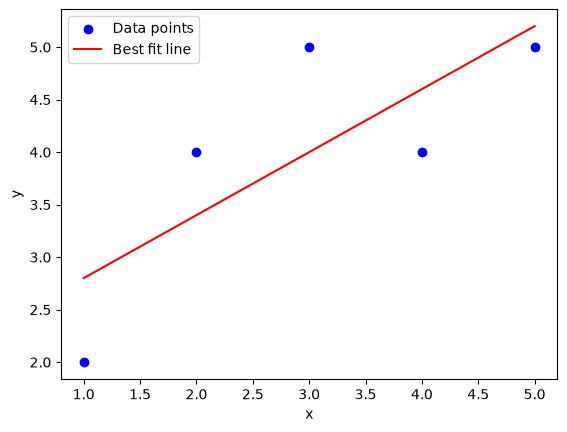

In [ ]:
# Code here
import numpy as np
import matplotlib.pyplot as plt

# Sample data
x = np.array([1, 2, 3, 4, 5])
y = np.array([2, 4, 5, 4, 5])
def mean(values):
    return np.sum(values) / len(values)

def calculate_slope(x, y):
    x_mean = mean(x)
    y_mean = mean(y)

    numerator = np.sum((x - x_mean) * (y - y_mean))
    denominator = np.sum((x - x_mean) ** 2)

    return numerator / denominator


def calculate_intercept(x, y, m):
    return mean(y) - m * mean(x)


def predict(x, m, b):
    return m * x + b

# Calculate slope and intercept
m = calculate_slope(x, y)
b = calculate_intercept(x, y, m)

print(f"Best fit line: y = {m:.2f}x + {b:.2f}")

# Plot the results
plt.scatter(x, y, color='blue', label='Data points')
plt.plot(x, predict(x, m, b), color='red', label='Best fit line')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

## **Exercise 3**

In this exercise, you'll create a simple LinearRegression class that encapsulates the functionality we've built in the previous exercises. This class will serve as a stepping stone towards understanding how sklearn estimators work.

Your task is to:

- a) Create a LinearRegression class with fit() and predict() methods.
- b) Use your class to fit a line to given data and make predictions.
- c) Compare your results with sklearn's LinearRegression.

Here's a template to get you started:

```python
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression as SklearnLinearRegression

class LinearRegression:
    def __init__(self):
        self.slope = None
        self.intercept = None
    
    def fit(self, X, y):
        # Implement the fitting logic here
        # Hint: You can use the functions from the previous exercise
        pass
    
    def predict(self, X):
        # Implement the prediction logic here
        pass

# Generate sample data
np.random.seed(0)
X = np.random.rand(100, 1)
y = 2 + 3 * X + np.random.randn(100, 1) * 0.1

# Create and fit your model
model = LinearRegression()
model.fit(X, y)

# Create and fit sklearn's model for comparison
sklearn_model = SklearnLinearRegression()
sklearn_model.fit(X, y)

# Make predictions
X_test = np.array([[0], [1]])
y_pred = model.predict(X_test)
y_pred_sklearn = sklearn_model.predict(X_test)

# Print results
print("Your model:")
print(f"Slope: {model.slope:.4f}, Intercept: {model.intercept:.4f}")
print(f"Predictions: {y_pred.flatten()}")

print("\nSklearn model:")
print(f"Slope: {sklearn_model.coef_[0][0]:.4f}, Intercept: {sklearn_model.intercept_[0]:.4f}")
print(f"Predictions: {y_pred_sklearn.flatten()}")

# Plot results
plt.scatter(X, y, color='blue', label='Data points')
plt.plot(X_test, y_pred, color='red', label='Your model')
plt.plot(X_test, y_pred_sklearn, color='green', label='Sklearn model')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()
```

Your model:
Slope: 2.9937, Intercept: 2.0222
Predictions: [2.02221511 5.01590861]

Sklearn model:
Slope: 2.9937, Intercept: 2.0222
Predictions: [2.02221511 5.01590861]

Predictions match: True


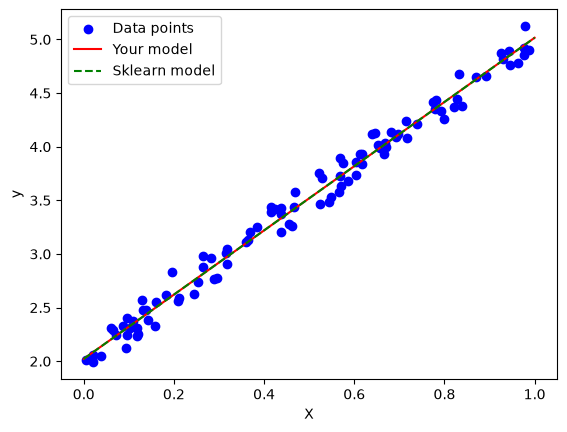

In [10]:
# Code here
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression as SklearnLinearRegression

class LinearRegression:
    def __init__(self):
        self.slope = None
        self.intercept = None

    def fit(self, X, y):
        x_mean = np.mean(X)
        y_mean = np.mean(y)

        numerator = np.sum((X - x_mean) * (y - y_mean))
        denominator = np.sum((X - x_mean) ** 2)

        self.slope = numerator / denominator
        self.intercept = y_mean - self.slope * x_mean

        return self

    def predict(self, X):
        return self.slope * X + self.intercept

# Generate sample data
np.random.seed(0)
X = np.random.rand(100, 1)
y = 2 + 3 * X + np.random.randn(100, 1) * 0.1

# Create and fit your model
model = LinearRegression()
model.fit(X, y)

# Create and fit sklearn's model
sklearn_model = SklearnLinearRegression()
sklearn_model.fit(X, y)

# Make predictions
X_test = np.array([[0], [1]])
y_pred = model.predict(X_test)
y_pred_sklearn = sklearn_model.predict(X_test)

# Print results
print("Your model:")
print(f"Slope: {model.slope:.4f}, Intercept: {model.intercept:.4f}")
print(f"Predictions: {y_pred.flatten()}")

print("\nSklearn model:")
print(f"Slope: {sklearn_model.coef_[0][0]:.4f}, Intercept: {sklearn_model.intercept_[0]:.4f}")
print(f"Predictions: {y_pred_sklearn.flatten()}")

print("\nPredictions match:", np.allclose(y_pred, y_pred_sklearn))

# Plot results
plt.scatter(X, y, color='blue', label='Data points')
plt.plot(X_test, y_pred, color='red', label='Your model')
plt.plot(X_test, y_pred_sklearn, color='green',
         linestyle='--', label='Sklearn model')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

## __Exercise 4__

In this exercise, you'll create a sklearn-compatible LinearRegression estimator. This will help you understand how sklearn's API works and how to create custom estimators that can be used with other sklearn tools.

Your task is to:

- a) Create a LinearRegression class that inherits from sklearn's BaseEstimator and RegressorMixin.
- b) Implement fit(), predict(), and score() methods according to sklearn's conventions.
- c) Use your estimator in a sklearn Pipeline and with cross-validation.

Here's a template to get you started:

```python
import numpy as np
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.utils.validation import check_X_y, check_array, check_is_fitted
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

class LinearRegression(BaseEstimator, RegressorMixin):
    def __init__(self):
        self.coef_ = None
        self.intercept_ = None

    def fit(self, X, y):
        # Check that X and y have correct shape
        X, y = check_X_y(X, y)
        
        # Implement the fitting logic here
        # Hint: Use np.linalg.lstsq for an efficient solution
        
        return self

    def predict(self, X):
        # Check is fit had been called
        check_is_fitted(self)

        # Input validation
        X = check_array(X)
        
        # Implement prediction logic here
        
        return predictions

    def score(self, X, y):
        # Implement R^2 score calculation here
        pass

# Generate sample data
np.random.seed(0)
X = np.random.rand(100, 1)
y = 2 + 3 * X + np.random.randn(100, 1) * 0.1

# Create and fit your model
model = LinearRegression()
model.fit(X, y)

# Use in a pipeline
pipeline = make_pipeline(StandardScaler(), LinearRegression())
pipeline.fit(X, y)

# Perform cross-validation
cv_scores = cross_val_score(pipeline, X, y, cv=5)

print(f"Model coefficients: {model.coef_}")
print(f"Model intercept: {model.intercept_}")
print(f"Cross-validation scores: {cv_scores}")
print(f"Mean CV score: {np.mean(cv_scores):.4f}")
```

In [ ]:
# Code here
import numpy as np
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.utils.validation import check_X_y, check_array, check_is_fitted
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score

class LinearRegression(RegressorMixin, BaseEstimator):
    def __init__(self):
        pass

    def fit(self, X, y):
       
        X, y = check_X_y(X, y)
        self.n_features_in_ = X.shape[1]

        
        X_with_intercept = np.column_stack((np.ones(X.shape[0]), X))

       
        parameters = np.linalg.lstsq(
            X_with_intercept, y, rcond=None
        )[0]

        self.intercept_ = parameters[0]
        self.coef_ = parameters[1:]

        return self

    def predict(self, X):
        
        check_is_fitted(self, ["coef_", "intercept_"])

        
        X = check_array(X)
        if X.shape[1] != self.n_features_in_:
            raise ValueError("X must have the same number of features as training data.")

        return X @ self.coef_ + self.intercept_

    def score(self, X, y):
        return r2_score(y, self.predict(X))

# Generate sample data
np.random.seed(0)
X = np.random.rand(100, 1)
y = (2 + 3 * X + np.random.randn(100, 1) * 0.1).ravel()

# Create and fit your model
model = LinearRegression()
model.fit(X, y)

# Use in a pipeline
pipeline = make_pipeline(StandardScaler(), LinearRegression())
pipeline.fit(X, y)

# Perform cross-validation
cv_scores = cross_val_score(pipeline, X, y, cv=5)

print(f"Model coefficients: {model.coef_}")
print(f"Model intercept: {model.intercept_}")
print(f"Cross-validation scores: {cv_scores}")
print(f"Mean CV score: {np.mean(cv_scores):.4f}")

Model coefficients: [2.9936935]
Model intercept: 2.0222151077447235
Cross-validation scores: [0.98597322 0.97779424 0.98708494 0.98633941 0.98659743]
Mean CV score: 0.9848
